# Apply syndrome-based decoding technique for Hamming(7,4) codes

In [1]:
import numpy as np
import pyldpc as ldpc
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
%matplotlib inline
%config InlineBackend.figure_format='retina'

In [2]:
k = 4
N = 7

In [3]:
# Create gen and parity check matrices
H = np.array([[1, 0, 1, 0, 1, 0, 1],
              [0, 1, 1, 0, 0, 1, 1],
              [0, 0, 0, 1, 1, 1, 1]])

G = ldpc.coding_matrix(H).T

In [4]:
def full_adder(a,b,c):
    s = (a ^ b) ^ c
    c = (a & b) | (c & (a ^ b))
    return s,c

def add_bool(a,b):
    if len(a) != len(b):
        raise ValueError('arrays with different length')
    k = len(a)
    s = np.zeros(k,dtype=bool)
    c = False
    for i in reversed(range(0,k)):
        s[i], c = full_adder(a[i],b[i],c)    
    if c:
        warnings.warn("Addition overflow!")
    return s

def inc_bool(a):
    k = len(a)
    increment = np.hstack((np.zeros(k-1,dtype=bool), np.ones(1,dtype=bool)))
    a = add_bool(a,increment)
    return a

In [5]:
# Generate information and code words
inputs = np.zeros((2**k,k),dtype=bool)
for i in range(1,2**k):
    inputs[i]= inc_bool(inputs[i-1])
codewords = inputs @ G % 2

In [6]:
# Generate array with all possible 7-bit combinations
combinations = np.zeros((2**N,N),dtype=bool)
for i in range(1,2**N):
    combinations[i] = inc_bool(combinations[i-1])

In [7]:
# Syndrome can take value in range from b000 to b111, so zero axis of matrix must have size of 8.
# Possible channel values will be assigned to the 1st and 2nd axis of the matrix.
# Initial matrix is filled with inf valeus
errors_sorted = np.full((8, 128, 7), np.inf)
for i, elem in enumerate(combinations):
    synd = int(np.packbits((elem @ H.T % 2), bitorder='little'))     # Calculate syndrom and convert in to int index 
    errors_sorted[synd][i] = elem                                    # Distribute possible channel states according to syndrom values

In [8]:
# In Hamming code syndrome value shows in which bit error was made
for i in range(0, errors_sorted.shape[0]):
    print(i, np.argmin(np.sum(errors_sorted, axis=2)[i]), np.min(np.sum(errors_sorted, axis=2)[i]), errors_sorted[i][np.argmin(np.sum(errors_sorted, axis=2)[i])])

0 0 0.0 [0. 0. 0. 0. 0. 0. 0.]
1 64 1.0 [1. 0. 0. 0. 0. 0. 0.]
2 32 1.0 [0. 1. 0. 0. 0. 0. 0.]
3 16 1.0 [0. 0. 1. 0. 0. 0. 0.]
4 8 1.0 [0. 0. 0. 1. 0. 0. 0.]
5 4 1.0 [0. 0. 0. 0. 1. 0. 0.]
6 2 1.0 [0. 0. 0. 0. 0. 1. 0.]
7 1 1.0 [0. 0. 0. 0. 0. 0. 1.]


# Simulate and plot BER

In [9]:
class ProgressParallel(Parallel):
    def __init__(self, use_tqdm=True, total=None, desc='', *args, **kwargs):
        self._use_tqdm = use_tqdm
        self._total = total
        self._desc = desc
        super().__init__(*args, **kwargs)

    def __call__(self, *args, **kwargs):
        with tqdm(disable=not self._use_tqdm, total=self._total, desc=self._desc) as self._pbar:
            return Parallel.__call__(self, *args, **kwargs)

    def print_progress(self):
        if self._total is None:
            self._pbar.total = self.n_dispatched_tasks
        self._pbar.n = self.n_completed_tasks
        self._pbar.refresh()


def simulate(sigmas, max_errors, experiment_func, k , N):
    
    def simulation(sigma):
        nb_errors, nb_bits = 0, 0
        while nb_errors < max_errors:
            nb_errors += experiment_func(sigma)
            nb_bits += k
        return nb_errors / nb_bits
    
    ber = np.asarray(ProgressParallel(n_jobs=-1, total=len(sigmas))([delayed(simulation)(sigma) for sigma in sigmas]))
    plt.figure(figsize = (10, 6))
    plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), ber)
    plt.yscale('log')
    plt.xlabel('$E_b/N_0$')
    plt.ylabel('BER')
    plt.grid()
    return ber

In [10]:
def encode(x):
    return x @ G % 2

def modulateBPSK(x):
    return -2*x +1;

def addNoise(x, sigma):
    w = np.random.normal(loc=0, scale=sigma, size=(N,))
    return x + w

def demodulateBPSK(x):
    return (-(np.sign(x) - 1)/2).astype(int)

def decode(x):
    synd_idx = int(np.packbits((x.astype(int) @ H.T % 2), bitorder='little'))
    err_vect_idx = np.argmin(np.sum(errors_sorted, axis=2)[synd_idx])
    cw =  x.astype(bool) ^ errors_sorted[synd_idx, err_vect_idx].astype(bool)
    return cw[[2,4,5,6]]

def syndrome_decoder(sigma):
    idx = np.random.randint(0, 2**k)
    cw = encode(inputs[idx])
    s = modulateBPSK(cw)
    y = addNoise(s, sigma)
    y = demodulateBPSK(y)
    x_hat = decode(y)
    return np.sum(np.not_equal(inputs[idx], x_hat).astype(int))

In [11]:
test_size = 10**5

SNR_dB_start_Eb = -10
SNR_dB_stop_Eb = 5
SNR_points = 20

SNR_dB_start_Es = SNR_dB_start_Eb + 10*np.log10(k/N)
SNR_dB_stop_Es = SNR_dB_stop_Eb + 10*np.log10(k/N)

sigma_start = np.sqrt(1/(2*10**(SNR_dB_start_Es/10)))
sigma_stop = np.sqrt(1/(2*10**(SNR_dB_stop_Es/10)))
sigmas = np.linspace(sigma_start, sigma_stop, SNR_points)

  0%|          | 0/20 [00:00<?, ?it/s]

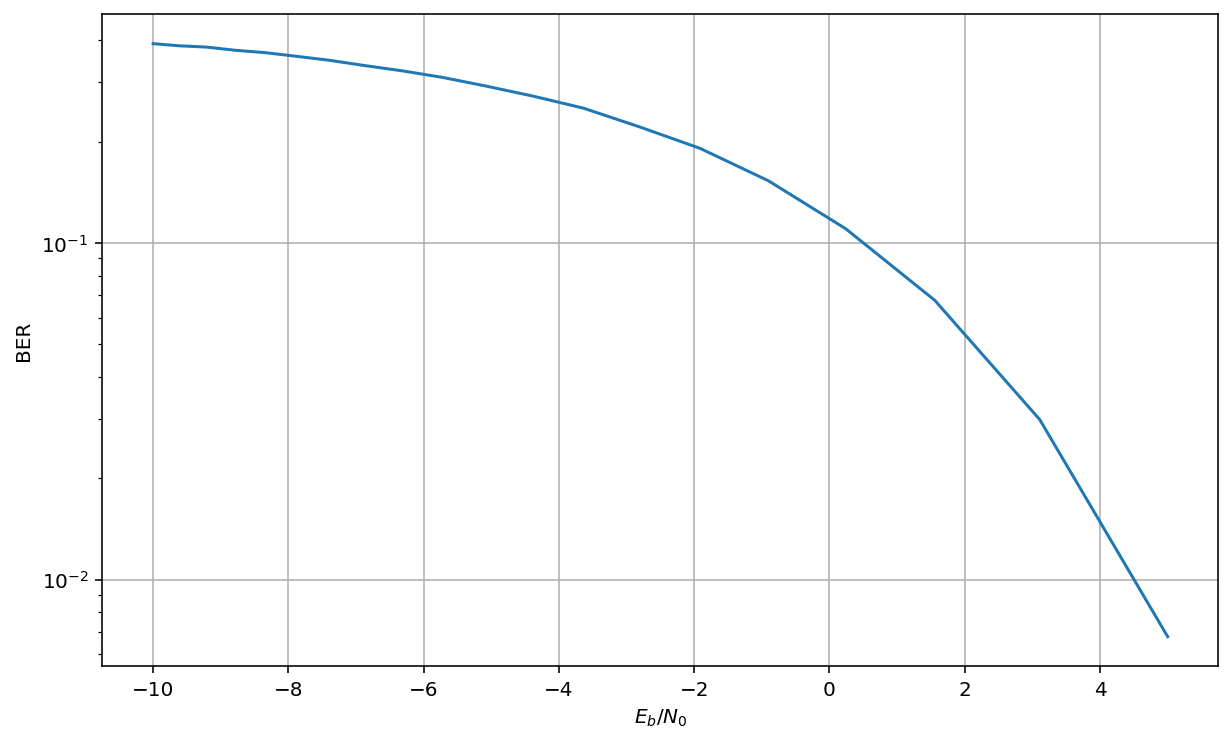

In [12]:
ber_ret = simulate(sigmas, test_size, syndrome_decoder, k, N)

In [16]:
np.savetxt('ML_hamming74_-10_5_ber.txt', ber_ret)

In [14]:
sigmas

array([2.95803989, 2.83003896, 2.70203802, 2.57403709, 2.44603616,
       2.31803522, 2.19003429, 2.06203335, 1.93403242, 1.80603148,
       1.67803055, 1.55002962, 1.42202868, 1.29402775, 1.16602681,
       1.03802588, 0.91002495, 0.78202401, 0.65402308, 0.52602214])

In [15]:
np.savetxt('ML_hamming74_-10_5_sigmas.txt', sigmas)